In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,root_mean_squared_error,r2_score

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("sakshisatre/ice-cream-sales-dataset")

path += '\\Ice Cream.csv'
print(path)

C:\Users\harry\.cache\kagglehub\datasets\sakshisatre\ice-cream-sales-dataset\versions\1\Ice Cream.csv


In [3]:
icecream_sales = pd.read_csv(path)

In [4]:
icecream_sales.head()

,Temperature,Revenue
0,24.6,535
1,26.1,626
2,27.8,661
3,20.6,488
4,11.6,317


In [5]:
icecream_sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Temperature  500 non-null    float64
 1   Revenue      500 non-null    int64  
dtypes: float64(1), int64(1)
memory usage: 7.9 KB


In [6]:
icecream_sales.describe().T

,count,mean,std,min,25%,50%,75%,max
Temperature,500.0,22.2816,8.097597,0.0,17.175,22.4,27.8,45.0
Revenue,500.0,522.0580,175.410399,10.0,406.000,530.0,643.0,1000.0


In [7]:
icecream_sales.columns

Index(['Temperature', 'Revenue'], dtype='object')

In [8]:
icecream_sales.shape

(500, 2)

In [9]:
X,y = icecream_sales[['Temperature']], icecream_sales[['Revenue']]

In [10]:
X.shape

(500, 1)

Text(0, 0.5, 'Revenue from Ice-cream')

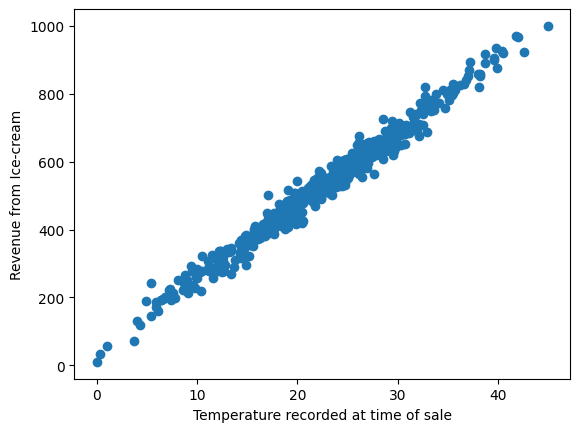

In [11]:
plt.scatter(X,y)
plt.xlabel("Temperature recorded at time of sale")
plt.ylabel("Revenue from Ice-cream")

In [12]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=2)

In [13]:
# X_train
# X_test
# y_train
# y_test

In [14]:
icecream_sales_model = LinearRegression()
icecream_sales_model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
y_pred = icecream_sales_model.predict(X_test)
# y_pred

Text(0, 0.5, 'Revenue from Ice-cream')

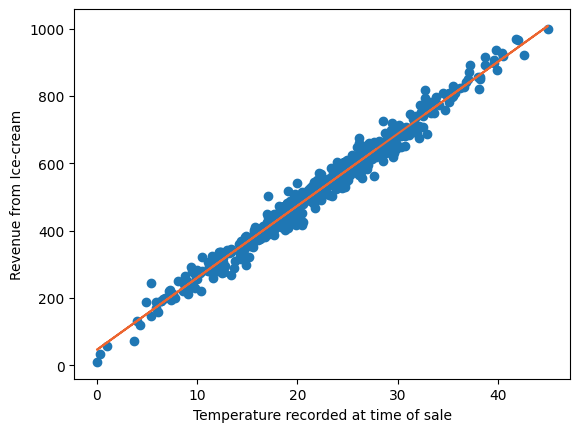

In [16]:
plt.scatter(X,y)
plt.plot(X_train,icecream_sales_model.predict(X_train),color ='#EC6530')
plt.xlabel("Temperature recorded at time of sale")
plt.ylabel("Revenue from Ice-cream")

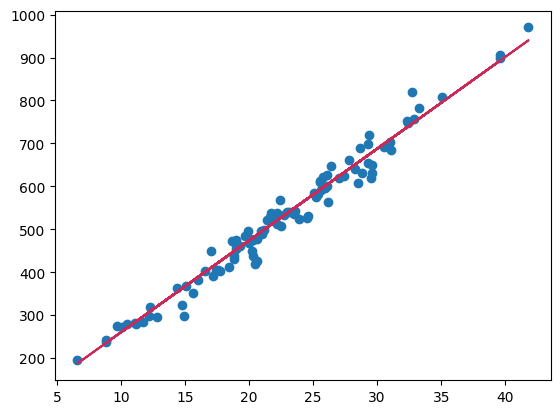

In [17]:
plt.scatter(X_test,y_test)
plt.plot(X_test, y_pred, color = '#CB2957')

In [18]:
print("Slope:", icecream_sales_model.coef_[0])
print("Intercept:", icecream_sales_model.intercept_)

Slope: [21.37960235]
Intercept: [46.19065783]


In [19]:
print("Mean Absolute Error : ",mean_absolute_error(y_test,y_pred))

Mean Absolute Error :  19.113064651627443


In [20]:
print("Mean Squared Error : ",mean_squared_error(y_test,y_pred))

Mean Squared Error :  634.6661011120311


In [21]:
print("Root Mean Squared Error : ",root_mean_squared_error(y_test,y_pred))

Root Mean Squared Error :  25.192580278963707


In [22]:
r2 = r2_score(y_test,y_pred)
print("r2score : ", r2)

r2score :  0.9736146932014387


In [23]:
adR2 = 1 - (((1 - r2)*(len(X_test) - 1))/(len(X_test) - 1 - len(X_test.columns)))
print("Adjusted R2 Score : ", adR2)

Adjusted R2 Score :  0.9733454553769636


In [24]:
import pickle

with open("ice-cream_model.pkl", "wb") as file:
    pickle.dump(icecream_sales_model, file)

print("Model saved successfully!")

Model saved successfully!
